In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import ttest_ind
from sklearn.metrics import mean_squared_error
import hydroeval as he


In [2]:
#read in MUSICA cleaned and paired timeseries
mus_obs = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/MUSICA Cleaned Paired Modeled Observed Timeseries.csv', parse_dates = ['dateOnround', 'dateOffround'])
mus_obs['Resolution'] = 'MUSICA'
mus_obs.columns

Index(['Unnamed: 0', 'siteId', 'SamplingInt', 'dateOnround', 'dateOffround',
       'lat', 'lon', 'Modelled', 'Observed', 'Variable', 'Percent_Error',
       'Precip_Percent_Error', 'Month', 'Resolution'],
      dtype='object')

In [3]:
# read in Global cleaned and paired timeseries and truncate to the same timeperiod as ^^
glob_obs = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Cleaned Paired Modeled Observed Timeseries.csv', parse_dates = ['dateOnround', 'dateOffround'])

start = dt.datetime.strptime('2016-12-31', '%Y-%m-%d')
end = dt.datetime.strptime('2018-12-31', '%Y-%m-%d')
glob_obs = glob_obs.loc[(glob_obs.dateOnround > start) & (glob_obs.dateOffround < end),]
glob_obs['Resolution'] = 'Global'
glob_obs = glob_obs.rename(columns = {'latitude': 'lat'})
glob_obs = glob_obs.drop(columns=['longitude'])
glob_obs.columns

Index(['Unnamed: 0', 'siteId', 'SamplingInt', 'dateOnround', 'dateOffround',
       'lat', 'lon', 'Modelled', 'Observed', 'Variable', 'Percent_Error',
       'Precip_Percent_Error', 'Month', 'Resolution'],
      dtype='object')

In [4]:
#Concat the musica and global results together for easier time running stats in loops:
glob_mus_obs = pd.concat([glob_obs, mus_obs])
glob_mus_obs

,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,lat,lon,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error,Month,Resolution
208,335354,MO05,964.0,2018-07-25,2018-08-01,36.9108,270.000000,15.602956,3.55600,Precipitation_mm,77.209446,77.209446,8,Global
209,335366,MO05,968.0,2018-08-22,2018-08-29,36.9108,270.000000,1.024027,2.03200,Precipitation_mm,98.432238,98.432238,8,Global
210,335370,MO05,969.0,2018-08-29,2018-09-05,36.9108,270.000000,4.626539,6.09600,Precipitation_mm,31.761552,31.761552,9,Global
211,335374,MO05,970.0,2018-09-05,2018-09-12,36.9108,270.000000,53.858965,76.96200,Precipitation_mm,42.895431,42.895431,9,Global
212,335382,MO05,973.0,2018-09-26,2018-10-03,36.9108,270.000000,22.323766,12.44600,Precipitation_mm,44.247758,44.247758,10,Global
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44622,69955,ME09,15.0,2018-07-11,2018-07-18,45.4891,290.421528,18.300411,17.87398,WetDep_DOC_mgm2,2.330173,59.231809,7,MUSICA
44623,69957,ME09,16.0,2018-08-22,2018-08-29,45.4891,290.421528,15.852645,5.79120,WetDep_DOC_mgm2,63.468556,85.169226,8,MUSICA
44624,70155,TF,75.0,2017-09-26,2017-10-03,43.1080,289.038375,1.483231,2.93800,WetDep_DOC_mgm2,98.081093,83.355149,10,MUSICA
44625,70153,TF,74.0,2017-09-19,2017-09-26,43.1080,289.038375,2.342831,4.28740,WetDep_DOC_mgm2,83.000831,87.829553,9,MUSICA


In [5]:
#for each Resolution and Variable, calcualte the RMSE and r2 between modeled and observed and save it in a table
results = []

for i in glob_mus_obs.Resolution.unique():
    res_df = glob_mus_obs.loc[glob_mus_obs.Resolution == i,]
    for j in res_df.Variable.unique():
        res_var_df = res_df.loc[res_df.Variable == j,]
        #mod_comp_temp = pd.DataFrame()
        RMSE = np.sqrt(mean_squared_error(res_var_df['Modelled'], res_var_df['Observed']))
        r2 = r2_score(res_var_df['Modelled'], res_var_df['Observed'])
        r = np.corrcoef(res_var_df['Modelled'], res_var_df['Observed'])
        nse = he.evaluator(he.nse, res_var_df['Modelled'], res_var_df['Observed'])
        kge, r, alpha, beta = he.evaluator(he.kge, res_var_df['Modelled'], res_var_df['Observed'])
        # Create a dictionary for the current iteration's results
        data = {
            'Resolution': i,
            'Variable': j,
            'RMSE': RMSE,
            'R²': r2,
            'R': r.item(),
            'NSE' : nse.item(),
            'KGE' : kge.item()
        }

        # Append the data as a new row to the mod_comp_temp DataFrame
        results.append(data)
        
mod_comp = pd.DataFrame(results)
mod_comp.sort_values(by='Variable', inplace=True)
mod_comp

,Resolution,Variable,RMSE,R²,R,NSE,KGE
0,Global,Precipitation_mm,16.501483,0.470003,0.759782,0.502370,0.693127
5,MUSICA,Precipitation_mm,22.370388,0.441589,0.713818,0.246642,0.567641
4,Global,WetDep_DOC_mgm2,10.930783,0.573005,0.783613,0.560968,0.783151
9,MUSICA,WetDep_DOC_mgm2,9.845732,-0.014459,0.794765,0.579659,0.559117
3,Global,WetDep_NH4_mgm2,1.563128,0.464319,0.844720,0.693538,0.685835
8,MUSICA,WetDep_NH4_mgm2,1.986385,0.452823,0.789291,0.619246,0.728118
2,Global,WetDep_NO3_mgm2,14.065315,0.120438,0.646075,-0.499343,0.195388
7,MUSICA,WetDep_NO3_mgm2,18.285730,0.025300,0.595822,-1.403336,-0.098470
1,Global,WetDep_SO4_mgm2,7.708191,0.289356,0.667437,-0.080444,0.373036
6,MUSICA,WetDep_SO4_mgm2,8.251305,0.243125,0.645625,-0.197460,0.318575


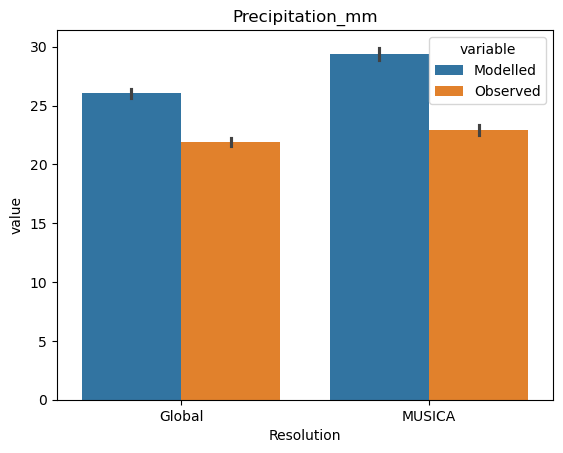

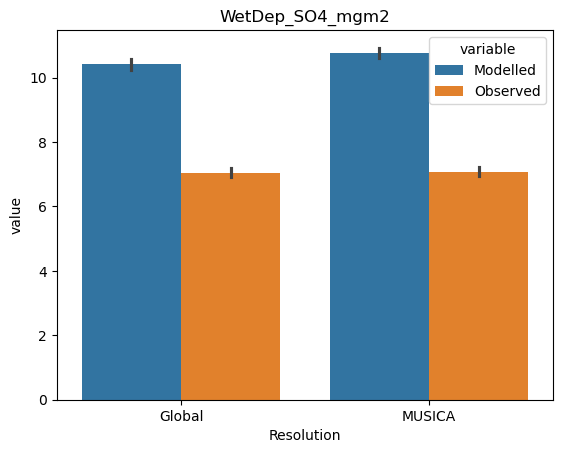

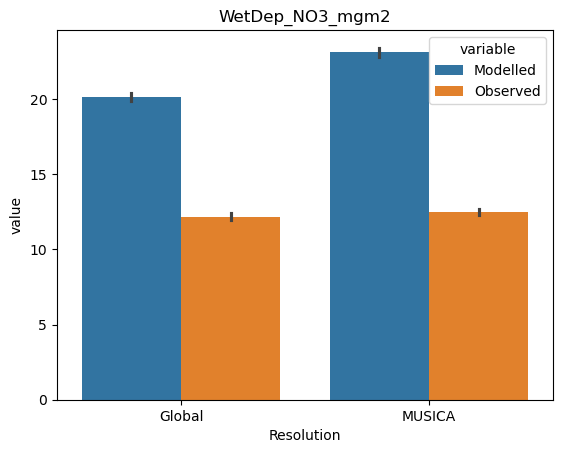

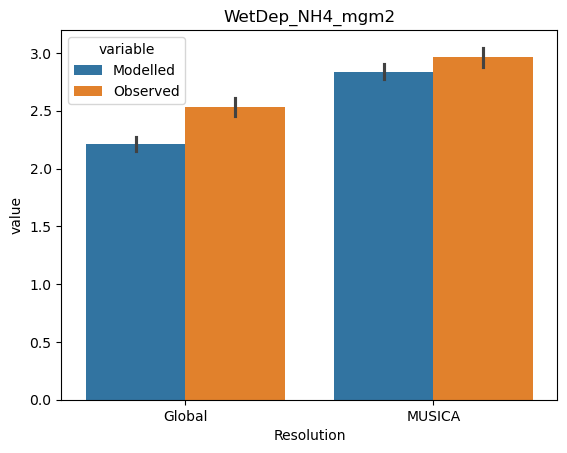

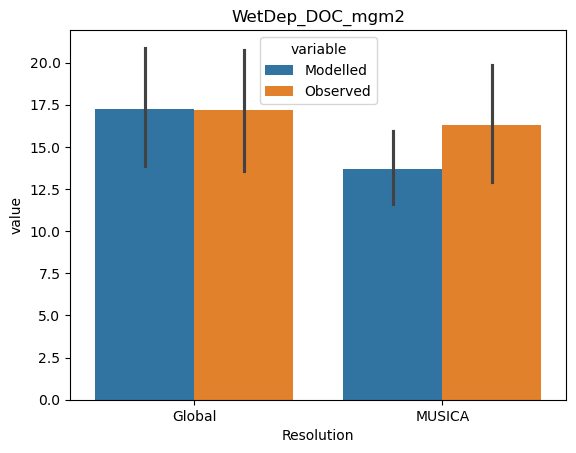

In [6]:
glob_mus_obs_plot = glob_mus_obs[['Resolution', 'Variable', 'Modelled', 'Observed']]

for i in glob_mus_obs_plot.Variable.unique():
    sub_df = glob_mus_obs_plot.loc[glob_mus_obs_plot.Variable == i,]
    sub_df_melt = pd.melt(sub_df, id_vars = ['Resolution', 'Variable'])
    sns.barplot(data=sub_df_melt, x="Resolution", y="value", hue="variable", estimator = 'mean')
    plt.title(i)
    plt.show()

In [7]:
glob_mus_obs_plot_stat = glob_mus_obs_plot.groupby(['Resolution', 'Variable'])[['Modelled', 'Observed']].mean()
glob_mus_obs_plot_stat

Modelled   Observed
Resolution Variable                              
Global     Precipitation_mm  26.032234  21.904798
           WetDep_DOC_mgm2   17.230367  17.195771
           WetDep_NH4_mgm2    2.215836   2.527826
           WetDep_NO3_mgm2   20.149214  12.176392
           WetDep_SO4_mgm2   10.412213   7.046308
MUSICA     Precipitation_mm  29.366887  22.925395
           WetDep_DOC_mgm2   13.710965  16.304729
           WetDep_NH4_mgm2    2.833307   2.966778
           WetDep_NO3_mgm2   23.126068  12.518196
           WetDep_SO4_mgm2   10.762175   7.071953

/glade/derecho/scratch/demurray/tmp/ipykernel_61175/842057994.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Precipitation (mm)', 'SO4 (mg/m2)', 'NO3 (mg/m2)', 'NH4 (mg/m2)', 'DOC (mg/m2)'])


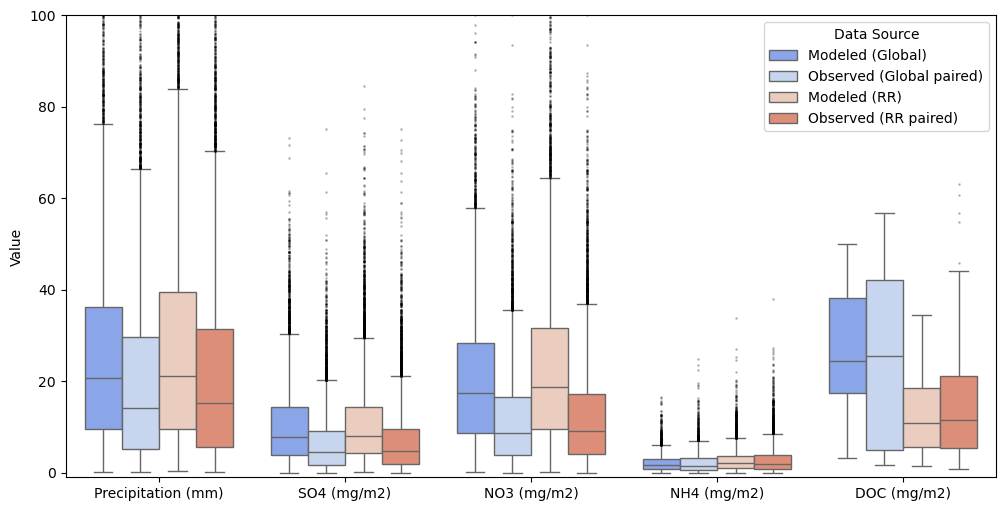

In [8]:
glob_obs_sub = glob_obs[['siteId', 'dateOnround', 'dateOffround', 'Variable', 'Modelled', 'Observed']]
glob_obs_sub = glob_obs_sub.rename(columns = {'Modelled': 'Modelled_Global', 'Observed': 'Observed_Global'})

mus_obs_sub = mus_obs[['siteId','dateOnround', 'dateOffround', 'Variable', 'Modelled', 'Observed']]
mus_obs_sub = mus_obs_sub.rename(columns = {'Modelled': 'Modelled_Musica', 'Observed': 'Observed_Musica'})
glob_obs_mus = pd.merge(glob_obs_sub, mus_obs_sub, on = ['siteId', 'dateOnround', 'dateOffround', 'Variable'], how = 'right')
test = pd.melt(glob_obs_mus, id_vars = [ 'siteId','dateOnround', 'dateOffround', 'Variable'], var_name = 'Source')

flierprops = dict(marker='o', markersize=1, linestyle='none', 
                  markerfacecolor='k', markeredgecolor='k', alpha=0.2)
custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Example custom colors
plt.figure(figsize=(12, 6))  # Adjust width (12) and height (6)
ax = sns.boxplot(data=test, x="Variable", y="value", hue = 'Source',  palette='coolwarm', flierprops=flierprops )#, estimator = 'mean')
plt.ylim(-1,100)
plt.xlabel('')
plt.ylabel('Value')
ax.set_xticklabels(['Precipitation (mm)', 'SO4 (mg/m2)', 'NO3 (mg/m2)', 'NH4 (mg/m2)', 'DOC (mg/m2)'])
handles, _ = ax.get_legend_handles_labels()  # Get existing handles and labels
ax.legend(handles=handles, labels=['Modeled (Global)', 'Observed (Global paired)', 'Modeled (RR)', 'Observed (RR paired)'], title='Data Source')
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Musica Global Obs Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

